In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv('/content/q1_heart_disease.csv')
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [48]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    object 
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    object 
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    object 
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 75.1+ KB


,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


The dataset contains 800 rows and 12 columns. Some columns such as resting_bp and cholesterol contain missing values. The dataset includes both numerical and categorical variables which will require preprocessing before model training.

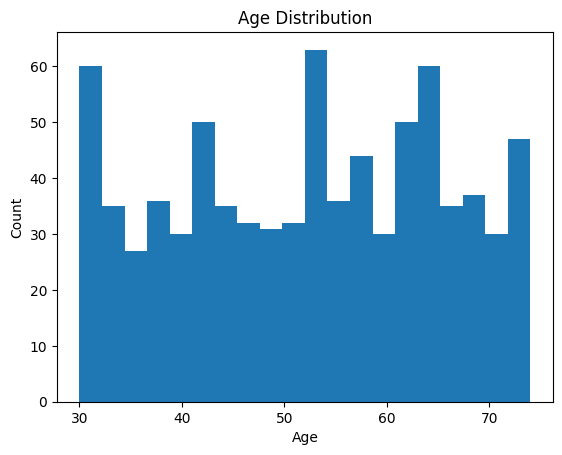

In [49]:
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The age distribution shows that most patients fall between 40 and 70 years, indicating that heart disease is more common among middle-aged and older individuals.

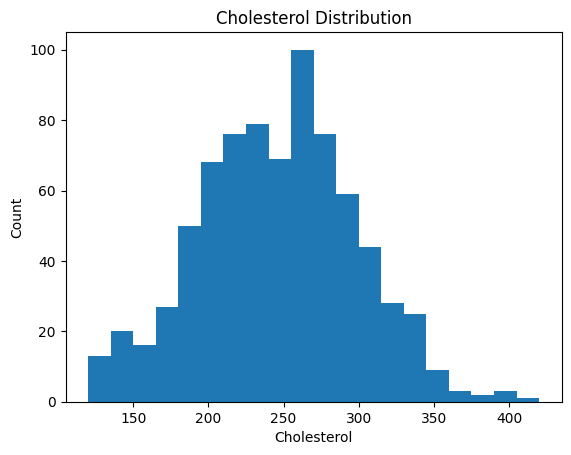

In [50]:
plt.hist(df['cholesterol'], bins=20)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.show()

Cholesterol levels are mostly concentrated between 200 and 300, suggesting that higher cholesterol may be associated with heart disease risk.

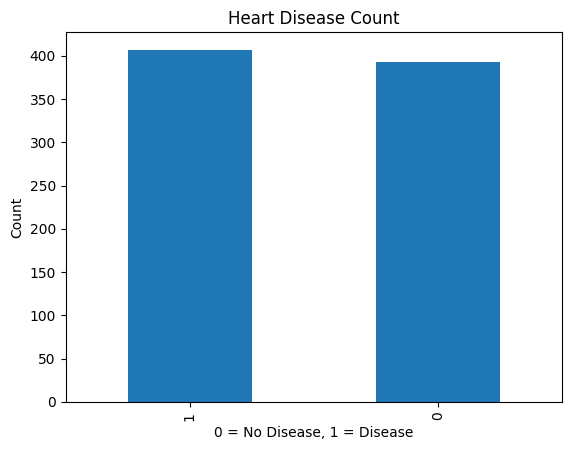

In [51]:
df['heart_disease'].value_counts().plot(kind='bar')
plt.title("Heart Disease Count")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.show()

The dataset is relatively balanced between patients with and without heart disease, which is beneficial for building a reliable classification model.

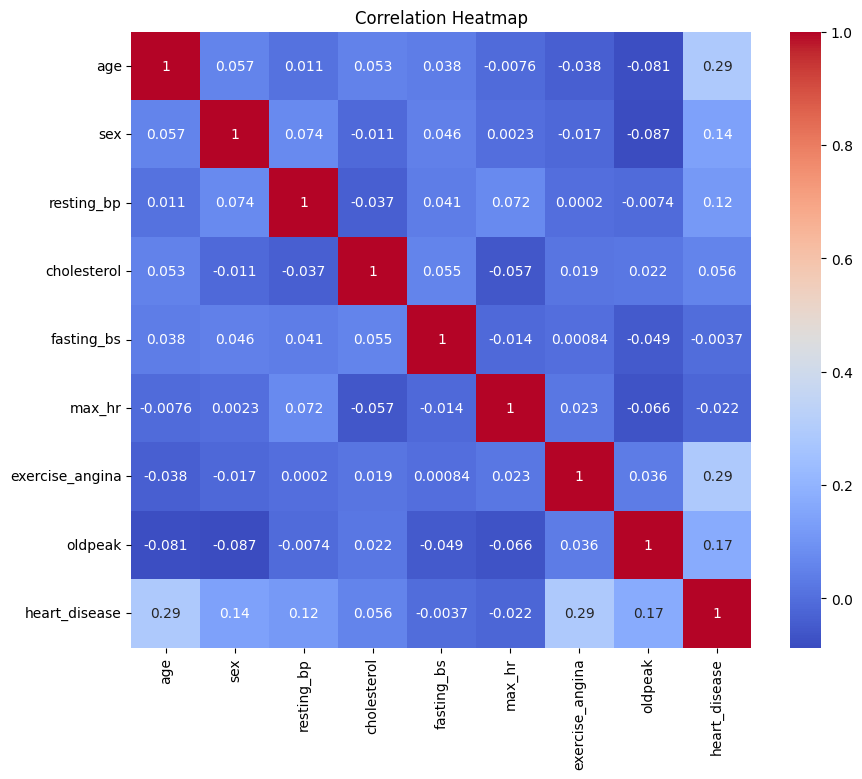

In [52]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships between variables. Features like oldpeak and max_hr show correlation with heart disease, indicating their importance in prediction.

In [53]:
# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

Missing values were handled using mean imputation. Categorical variables were converted into numerical form using one-hot encoding.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

The dataset was split into training (80%) and testing (20%) sets using stratified sampling to maintain class balance. Features were scaled using StandardScaler.

In [55]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [56]:
from sklearn.metrics import confusion_matrix, classification_report

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
[[62 17]
 [14 67]]
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        79
           1       0.80      0.83      0.81        81

    accuracy                           0.81       160
   macro avg       0.81      0.81      0.81       160
weighted avg       0.81      0.81      0.81       160



In [57]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
[[56 23]
 [25 56]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160



In [58]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
[[59 20]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        79
           1       0.77      0.81      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160



In [59]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
[[60 19]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        79
           1       0.77      0.77      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160



Among all models, Random Forest performed the best due to higher precision, recall, and F1-score. It handles complex patterns better than Logistic Regression and Decision Tree.

In [60]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


Hyperparameter tuning improved the performance of the Random Forest model by selecting optimal values. Overall, the model performs well in predicting heart disease and can be useful for early detection.

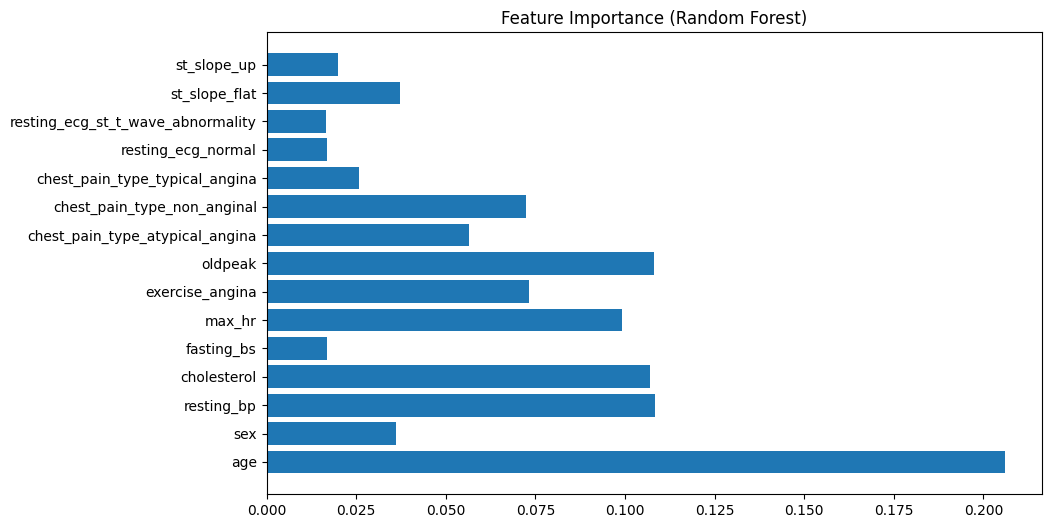

In [61]:
importances = rf.feature_importances_
features = df.drop('heart_disease', axis=1).columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

This project aimed to predict heart disease using supervised machine learning techniques. After performing data preprocessing and visualization, multiple models were trained and evaluated. Among them, Random Forest performed the best due to its ability to handle complex patterns and reduce overfitting. The model achieved good accuracy and balanced precision-recall values, making it reliable for prediction. This approach can help in early detection of heart disease and support medical decision-making.